<a href="https://colab.research.google.com/github/amit-devs/Amit_ML_Practicals/blob/main/Practical_9_ML_CS23091.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Amit Tiwari

**USN:** CS23091

**ML Lab-9**

**AIM: To implement the K-Means clustering algorithm and analyze the clustering results using appropriate evaluation techniques.**


In [ ]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/ML_DATASETS/Mall_Customers.csv'
df=pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
#step 3: Select Relevant Features
# For clustering, we usually select: Annual Income & Spending
# These features are used to segment customers.
X=df.iloc[:,[3,4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [ ]:
# step 4: feature scaling
# since k-means is distance-based, scaling is important
scaler =StandardScaler()
X_scaled = scaler.fit_transform(X)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


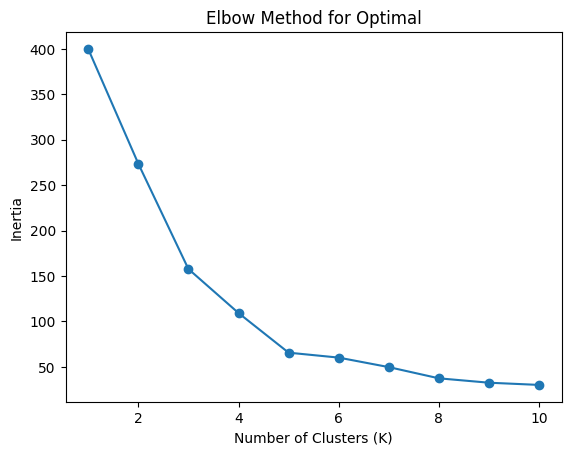

In [ ]:
# step 5: Determine optimal cluster(elbow method)
inertia_values = []
for k in range (1,11):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)
  # plotting elbow graph
plt.figure()
plt.plot(range(1,11),inertia_values,marker='o')
plt.title('Elbow Method for Optimal')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# step 6: apply k-means(assume k=5)
kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df['Cluster']=clusters
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
print("Inertia:",kmeans.inertia_)
sil_score=silhouette_score(X_scaled,clusters)
print("Sihouette Score:",sil_score)

Inertia: 65.56840815571681
Sihouette Score: 0.5546571631111091


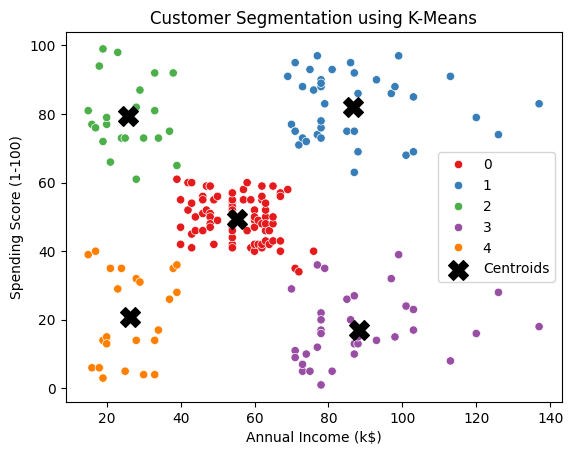

In [ ]:
plt.figure()
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='Cluster',
                data=df,
                palette='Set1'
                )
centroids=scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()